# Interpreting IQ Models: Landscapes, 3D Geometry, and Model Thinking

This notebook is an interpretability-first workflow for comparing complex and real IQ classifiers.

## 1) Setup and Imports

In [48]:
from pathlib import Path
import csv
import math

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from config import ModClassConfig
from data import generate_dataset, rotate_burst, generate_clean_burst, add_awgn
from models import build_model


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

cfg = ModClassConfig()
OUT_ROOT = Path(cfg.out_dir)
VIZ_DIR = Path('visualizations/geometry')
VIZ_DIR.mkdir(parents=True, exist_ok=True)

FAST_MODE = True

RUNS = {
    'complex_moment': ('complex_moment', 'tab:purple', 'Complex+Moments'),
    'complex_narrow': ('complex', 'tab:blue', 'Complex (narrow)'),
    'real_narrow': ('real', 'tab:red', 'Real (narrow)'),
    'real_full': ('real', 'tab:green', 'Real (full)'),
}

print(f'FAST_MODE = {FAST_MODE}')


Device: cuda
FAST_MODE = True


## 2) Load Trained Models and Shared Helpers

In [49]:
def load_model(run_name):
    model_type, _, _ = RUNS[run_name]
    model = build_model(model_type, cfg)

    ckpt = OUT_ROOT / run_name / 'best_model.pt'
    if not ckpt.exists():
        print(f'WARNING: checkpoint missing for {run_name}: {ckpt}')
        return None

    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.to(device)
    model.eval()
    return model


models = {name: load_model(name) for name in RUNS}
models = {k: v for k, v in models.items() if v is not None}
print('Loaded runs:', list(models.keys()))


class ActivationExtractor:
    def __init__(self, model):
        self.model = model
        self.activations = {}
        self.hooks = []
        for i, block in enumerate(model.features):
            h = block.register_forward_hook(self._hook(f'block_{i}'))
            self.hooks.append(h)

    def _hook(self, name):
        def fn(module, inp, out):
            self.activations[name] = out.detach().cpu()
        return fn

    def extract(self, x):
        self.activations = {}
        _ = self.model(x)
        return self.activations

    def remove(self):
        for h in self.hooks:
            h.remove()


def flatten_activation(acts):
    if acts.is_complex():
        acts = torch.cat([acts.real, acts.imag], dim=1)
    return acts.reshape(acts.shape[0], -1).cpu().numpy()


def to_model_input(iq_np):
    return torch.from_numpy(iq_np).to(device)


@torch.no_grad()
def evaluate_loss_acc(model, iq, label, batch_size=512):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for i in range(0, len(iq), batch_size):
        x = iq[i:i + batch_size]
        y = label[i:i + batch_size]
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total_loss += loss.item() * y.numel()
        total_correct += (logits.argmax(1) == y).sum().item()
        total += y.numel()
    return total_loss / max(total, 1), total_correct / max(total, 1)


def model_head_probs(model, iq, batch_size=512):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(iq), batch_size):
            p = F.softmax(model(iq[i:i + batch_size]), dim=-1).cpu().numpy()
            out.append(p)
    return np.concatenate(out, axis=0)


Loaded runs: ['complex_moment', 'complex_narrow', 'real_narrow', 'real_full']


## 3) Shared Evaluation Data

In [50]:
if FAST_MODE:
    n_landscape = 600
    n_repr = 1200
    n_probe = 1400
    n_orbit_angles = 24
    n_phase_eval = 24
else:
    n_landscape = 2400
    n_repr = 5000
    n_probe = 5000
    n_orbit_angles = 72
    n_phase_eval = 72

landscape_data = generate_dataset(
    n_landscape,
    cfg,
    -cfg.full_phase_deg,
    cfg.full_phase_deg,
    snr_db=cfg.snr_db,
    seed_offset=1001,
)

repr_data = generate_dataset(
    n_repr,
    cfg,
    -cfg.full_phase_deg,
    cfg.full_phase_deg,
    snr_db=cfg.snr_db,
    seed_offset=1002,
)

probe_data = generate_dataset(
    n_probe,
    cfg,
    -cfg.full_phase_deg,
    cfg.full_phase_deg,
    snr_db=cfg.snr_db,
    seed_offset=1003,
)

landscape_iq = to_model_input(landscape_data['iq'])
landscape_label = torch.from_numpy(landscape_data['label']).to(device)

repr_iq = to_model_input(repr_data['iq'])
repr_label = repr_data['label']
repr_theta = repr_data['theta']

print(f'Landscape samples: {len(landscape_data["iq"])}')
print(f'Representation samples: {len(repr_data["iq"])}')
print(f'Probe samples: {len(probe_data["iq"])}')


Landscape samples: 600
Representation samples: 1200
Probe samples: 1400


## 4) Loss Landscape (2D Contours + 3D Surfaces)

Computing landscape for complex_moment...


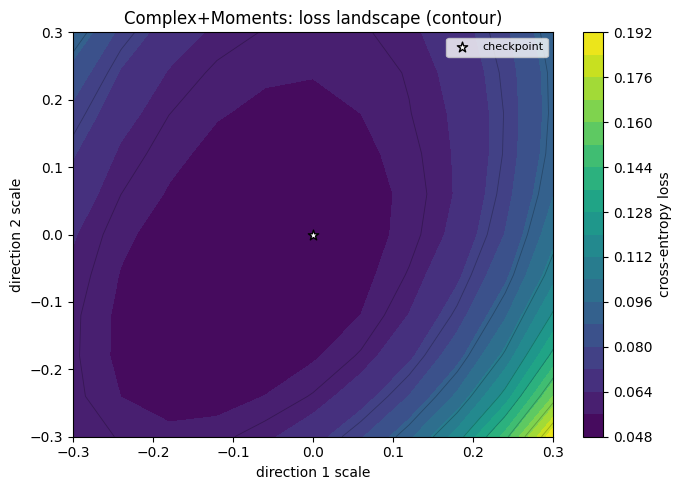

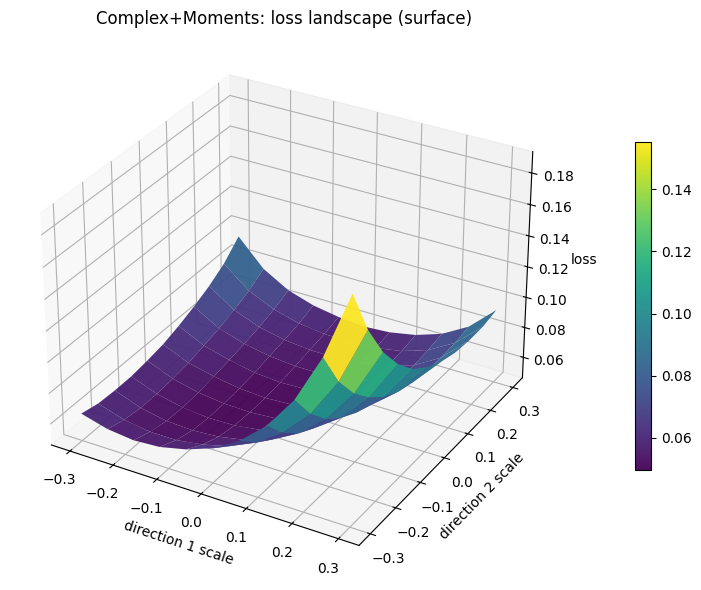

saved visualizations/geometry/complex_moment_loss_landscape_contour.png
saved visualizations/geometry/complex_moment_loss_landscape_surface.png
Computing landscape for complex_narrow...


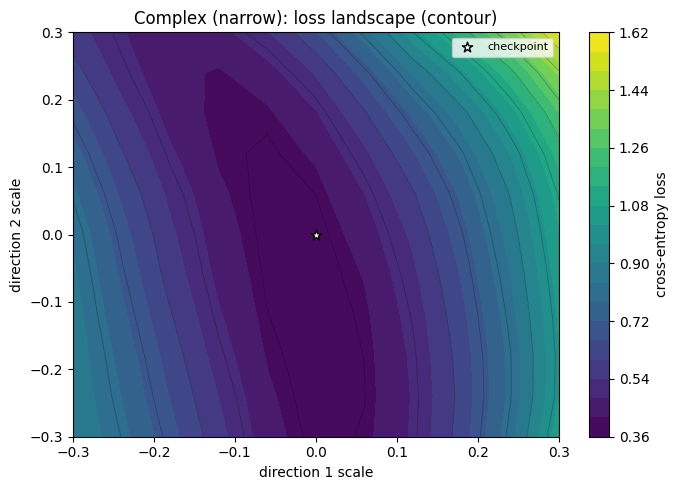

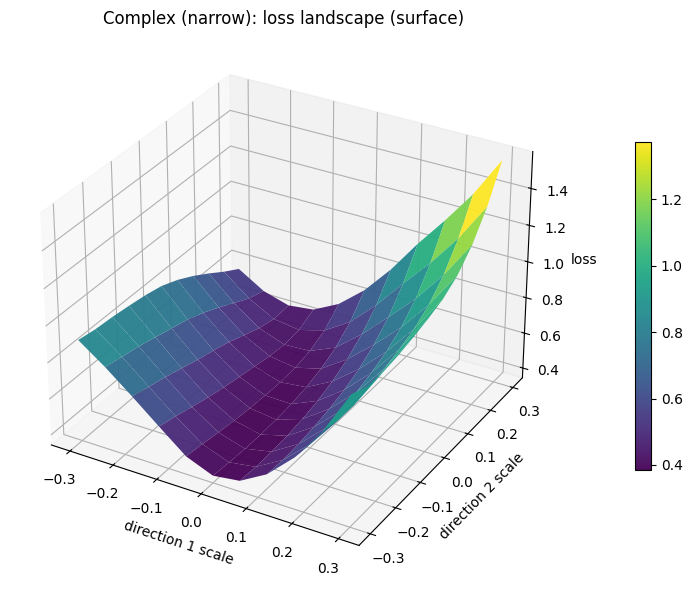

saved visualizations/geometry/complex_narrow_loss_landscape_contour.png
saved visualizations/geometry/complex_narrow_loss_landscape_surface.png
Computing landscape for real_narrow...


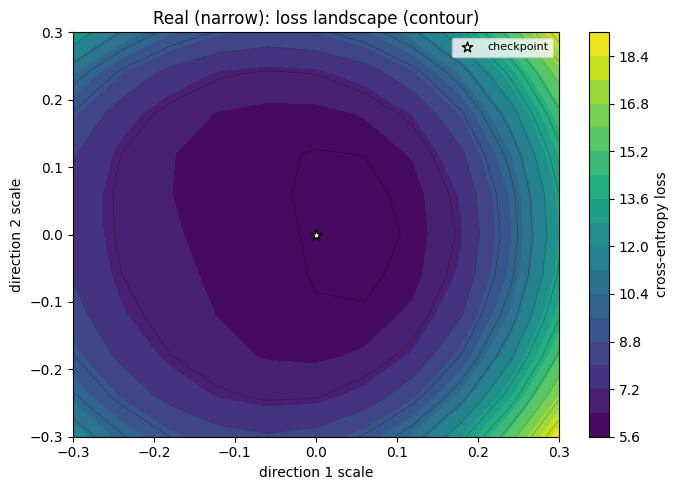

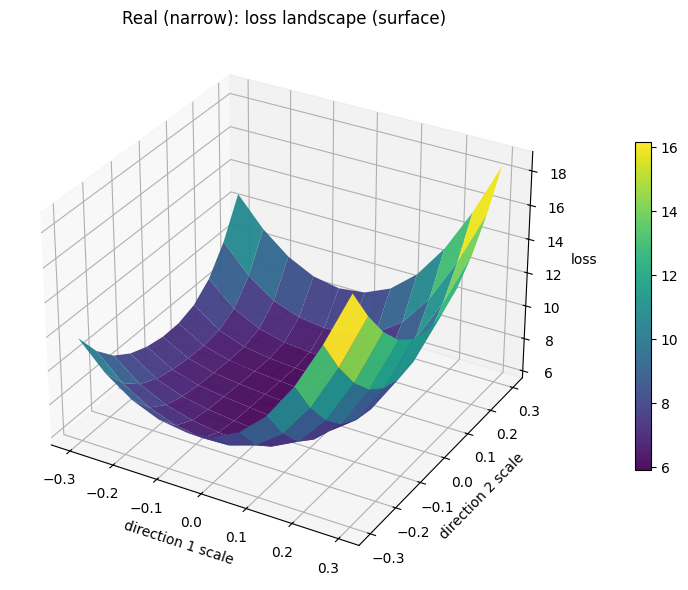

saved visualizations/geometry/real_narrow_loss_landscape_contour.png
saved visualizations/geometry/real_narrow_loss_landscape_surface.png
Computing landscape for real_full...


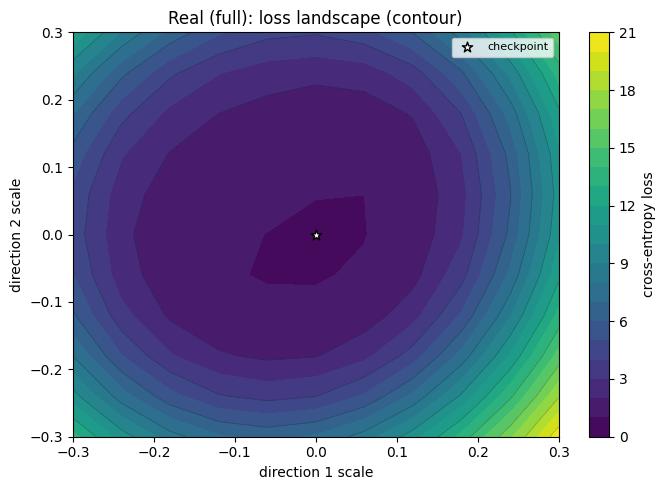

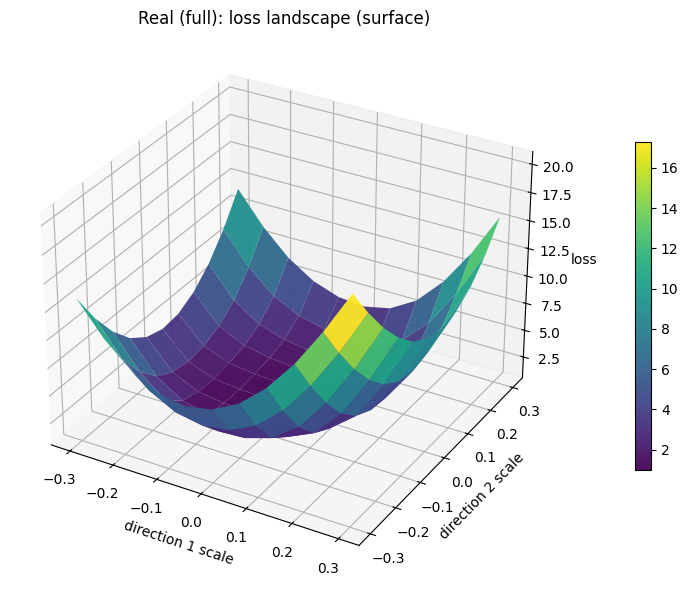

saved visualizations/geometry/real_full_loss_landscape_contour.png
saved visualizations/geometry/real_full_loss_landscape_surface.png


In [51]:
def _rand_like_param(p):
    if p.is_complex():
        return torch.randn_like(p.real) + 1j * torch.randn_like(p.real)
    return torch.randn_like(p)


def _direction_norm(direction):
    total = 0.0
    for d in direction:
        if d.is_complex():
            total += (d.abs() ** 2).sum().item()
        else:
            total += (d ** 2).sum().item()
    return math.sqrt(total)


def _scaled_random_direction(params, target_norm):
    direction = [_rand_like_param(p) for p in params]
    d_norm = _direction_norm(direction)
    scale = target_norm / (d_norm + 1e-12)
    return [d * scale for d in direction]


def _param_norm(params):
    return _direction_norm([p.detach() for p in params])


def _capture_params(model):
    return [p.detach().clone() for p in model.parameters() if p.requires_grad]


def _set_params(model, base, d1, d2, a, b):
    idx = 0
    with torch.no_grad():
        for p in model.parameters():
            if not p.requires_grad:
                continue
            p.copy_(base[idx] + a * d1[idx] + b * d2[idx])
            idx += 1


def compute_loss_landscape(model, radius=0.35, grid_size=15):
    params = [p for p in model.parameters() if p.requires_grad]
    base = _capture_params(model)
    p_norm = _param_norm(params)

    d1 = _scaled_random_direction(params, p_norm)
    d2 = _scaled_random_direction(params, p_norm)

    alphas = np.linspace(-radius, radius, grid_size)
    betas = np.linspace(-radius, radius, grid_size)
    losses = np.zeros((grid_size, grid_size), dtype=np.float64)
    accs = np.zeros((grid_size, grid_size), dtype=np.float64)

    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            _set_params(model, base, d1, d2, float(a), float(b))
            loss, acc = evaluate_loss_acc(model, landscape_iq, landscape_label)
            losses[i, j] = loss
            accs[i, j] = acc

    _set_params(model, base, d1, d2, 0.0, 0.0)

    center = losses[grid_size // 2, grid_size // 2]
    outer_ring = losses[[0, -1], :].mean() * 0.5 + losses[:, [0, -1]].mean() * 0.5
    sharpness = float(outer_ring - center)

    return {
        'alphas': alphas,
        'betas': betas,
        'losses': losses,
        'accs': accs,
        'center_loss': float(center),
        'sharpness_proxy': sharpness,
    }


def plot_loss_landscape(run_name, result):
    A, B = np.meshgrid(result['betas'], result['alphas'])
    Z = result['losses']

    fig, ax = plt.subplots(figsize=(7, 5))
    cs = ax.contourf(A, B, Z, levels=20, cmap='viridis')
    ax.contour(A, B, Z, levels=12, colors='k', alpha=0.25, linewidths=0.6)
    ax.scatter([0], [0], c='white', s=60, edgecolors='k', marker='*', label='checkpoint')
    ax.set_xlabel('direction 1 scale')
    ax.set_ylabel('direction 2 scale')
    ax.set_title(f'{RUNS[run_name][2]}: loss landscape (contour)')
    ax.legend(loc='best', fontsize=8)
    fig.colorbar(cs, ax=ax, label='cross-entropy loss')
    fig.tight_layout()
    contour_path = VIZ_DIR / f'{run_name}_loss_landscape_contour.png'
    fig.savefig(contour_path, dpi=160, bbox_inches='tight')
    plt.show()

    fig = plt.figure(figsize=(8, 6))
    ax3d = fig.add_subplot(111, projection='3d')
    surf = ax3d.plot_surface(A, B, Z, cmap='viridis', linewidth=0, antialiased=True, alpha=0.95)
    ax3d.set_xlabel('direction 1 scale')
    ax3d.set_ylabel('direction 2 scale')
    ax3d.set_zlabel('loss')
    ax3d.set_title(f'{RUNS[run_name][2]}: loss landscape (surface)')
    fig.colorbar(surf, ax=ax3d, shrink=0.6, pad=0.1)
    fig.tight_layout()
    surface_path = VIZ_DIR / f'{run_name}_loss_landscape_surface.png'
    fig.savefig(surface_path, dpi=160, bbox_inches='tight')
    plt.show()

    print(f'saved {contour_path}')
    print(f'saved {surface_path}')


landscape_results = {}
ls_grid = 11 if FAST_MODE else 21
for run_name, model in models.items():
    print(f'Computing landscape for {run_name}...')
    landscape_results[run_name] = compute_loss_landscape(model, radius=0.30, grid_size=ls_grid)
    plot_loss_landscape(run_name, landscape_results[run_name])


## 5) Weight Interpolation Barriers (Compatible Architectures)

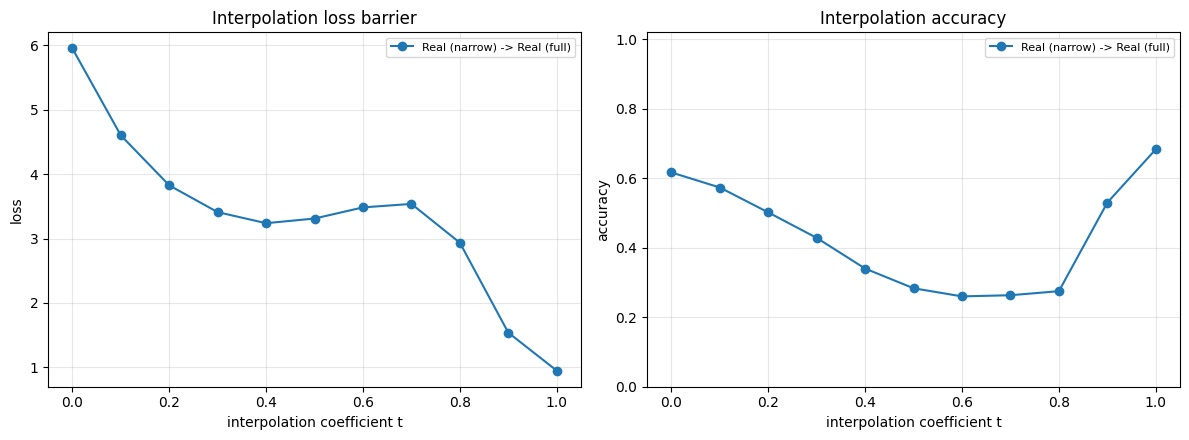

saved visualizations/geometry/interpolation_barriers.png


In [52]:
def same_structure_state_dict(sd_a, sd_b):
    if sd_a.keys() != sd_b.keys():
        return False
    for k in sd_a.keys():
        if sd_a[k].shape != sd_b[k].shape or sd_a[k].dtype != sd_b[k].dtype:
            return False
    return True


def interpolate_state_dict(sd_a, sd_b, t):
    return {k: (1.0 - t) * sd_a[k] + t * sd_b[k] for k in sd_a}


def evaluate_interpolation(run_a, run_b, t_values):
    model_type_a = RUNS[run_a][0]
    model_type_b = RUNS[run_b][0]
    if model_type_a != model_type_b:
        print(f'Skipping {run_a} vs {run_b}: different model families')
        return None

    ckpt_a = torch.load(OUT_ROOT / run_a / 'best_model.pt', map_location=device)
    ckpt_b = torch.load(OUT_ROOT / run_b / 'best_model.pt', map_location=device)

    if not same_structure_state_dict(ckpt_a, ckpt_b):
        print(f'Skipping {run_a} vs {run_b}: incompatible parameter structure')
        return None

    model = build_model(model_type_a, cfg).to(device)
    losses = []
    accs = []

    for t in t_values:
        interp = interpolate_state_dict(ckpt_a, ckpt_b, float(t))
        model.load_state_dict(interp)
        model.eval()
        loss, acc = evaluate_loss_acc(model, landscape_iq, landscape_label)
        losses.append(loss)
        accs.append(acc)

    endpoint = max(losses[0], losses[-1])
    barrier = float(max(losses) - endpoint)

    return {
        't': np.array(t_values),
        'loss': np.array(losses),
        'acc': np.array(accs),
        'barrier': barrier,
    }


t_values = np.linspace(0, 1, 11 if FAST_MODE else 31)
interpolation_pairs = [('real_narrow', 'real_full')]
interpolation_results = {}

for a, b in interpolation_pairs:
    if a in models and b in models:
        res = evaluate_interpolation(a, b, t_values)
        if res is not None:
            interpolation_results[(a, b)] = res

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for (a, b), res in interpolation_results.items():
    label = f'{RUNS[a][2]} -> {RUNS[b][2]}'
    axes[0].plot(res['t'], res['loss'], marker='o', label=label)
    axes[1].plot(res['t'], res['acc'], marker='o', label=label)

axes[0].set_title('Interpolation loss barrier')
axes[0].set_xlabel('interpolation coefficient t')
axes[0].set_ylabel('loss')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Interpolation accuracy')
axes[1].set_xlabel('interpolation coefficient t')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.legend(fontsize=8)

fig.tight_layout()
interp_path = VIZ_DIR / 'interpolation_barriers.png'
fig.savefig(interp_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'saved {interp_path}')


## 6) Internal 3D Representation Shapes (PCA-3)

Extracting and projecting activations for complex_moment...


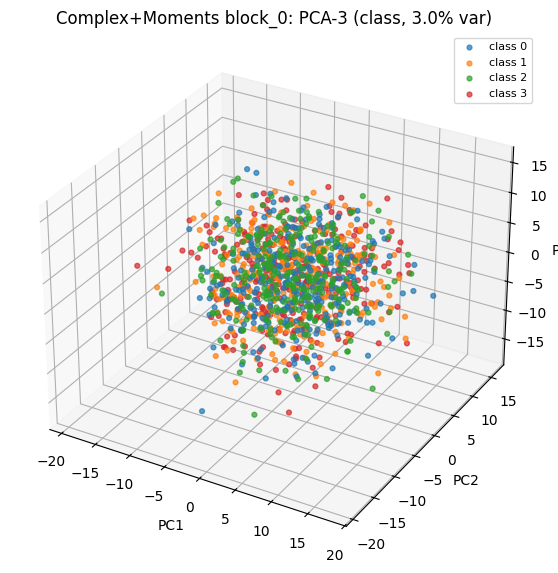

saved visualizations/geometry/complex_moment_block_0_pca3_class.png


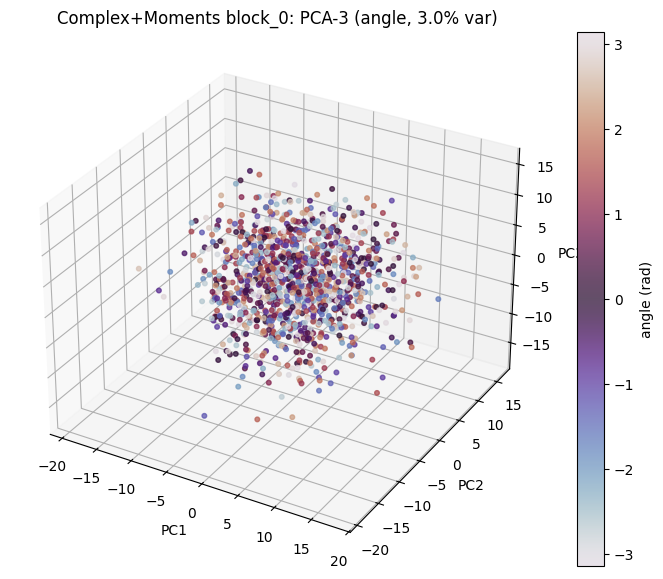

saved visualizations/geometry/complex_moment_block_0_pca3_angle.png


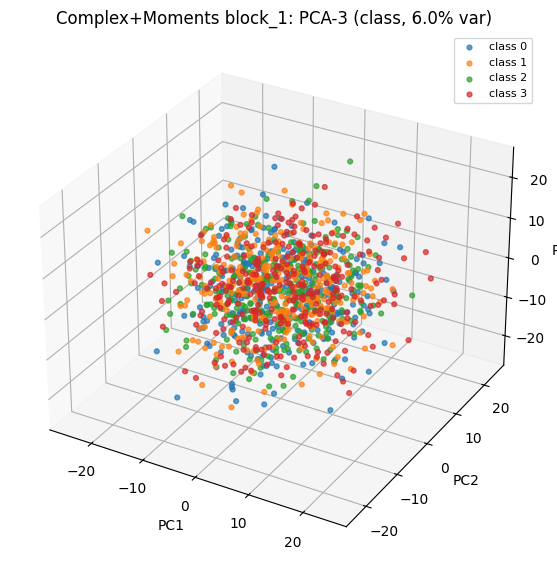

saved visualizations/geometry/complex_moment_block_1_pca3_class.png


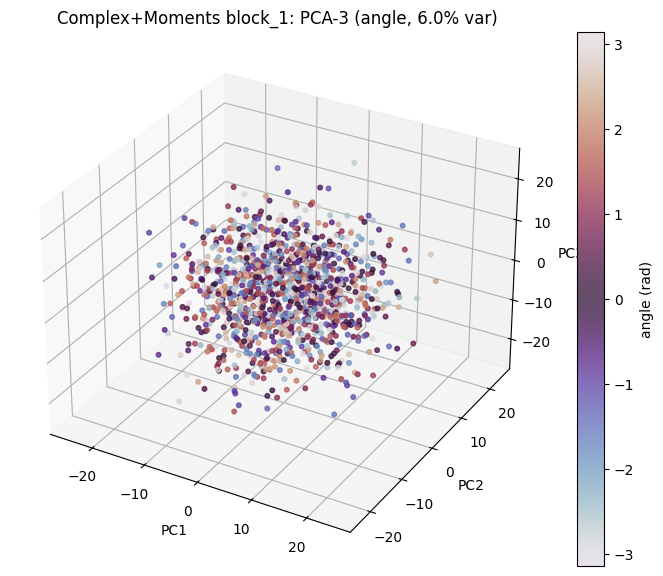

saved visualizations/geometry/complex_moment_block_1_pca3_angle.png


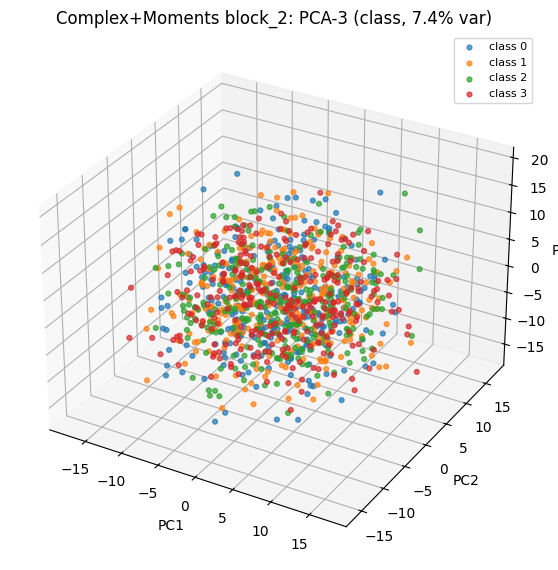

saved visualizations/geometry/complex_moment_block_2_pca3_class.png


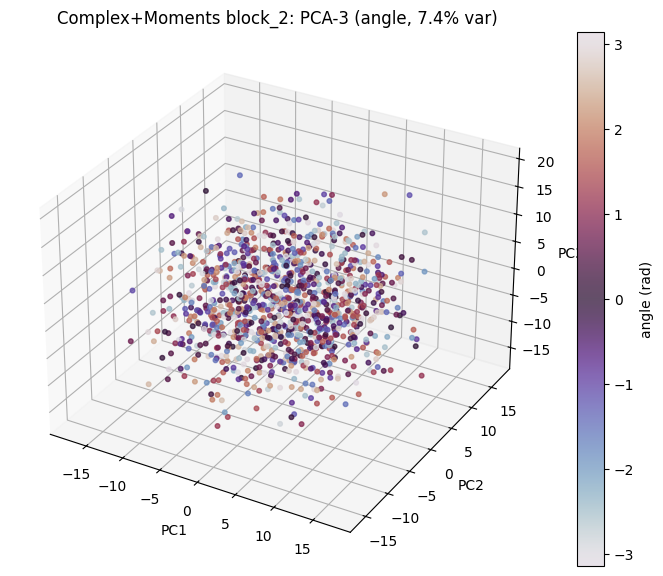

saved visualizations/geometry/complex_moment_block_2_pca3_angle.png
Extracting and projecting activations for complex_narrow...


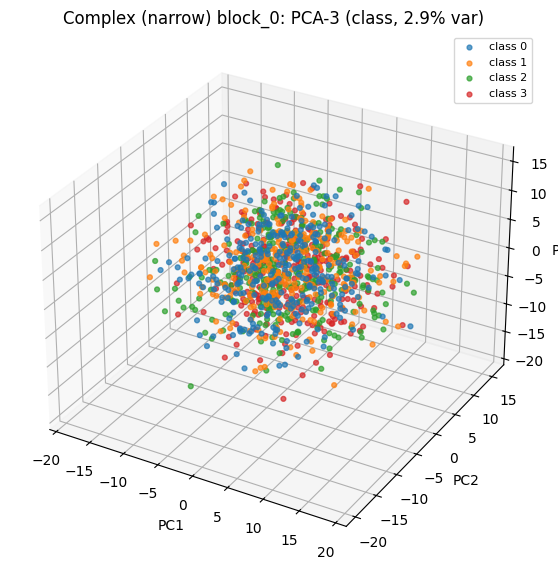

saved visualizations/geometry/complex_narrow_block_0_pca3_class.png


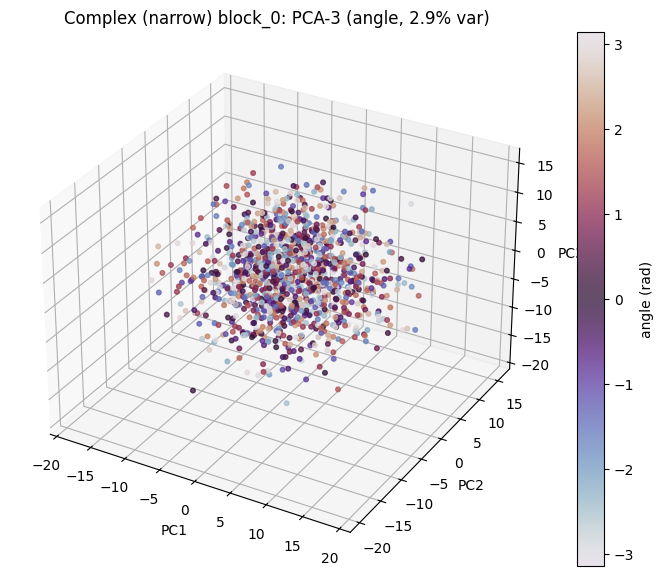

saved visualizations/geometry/complex_narrow_block_0_pca3_angle.png


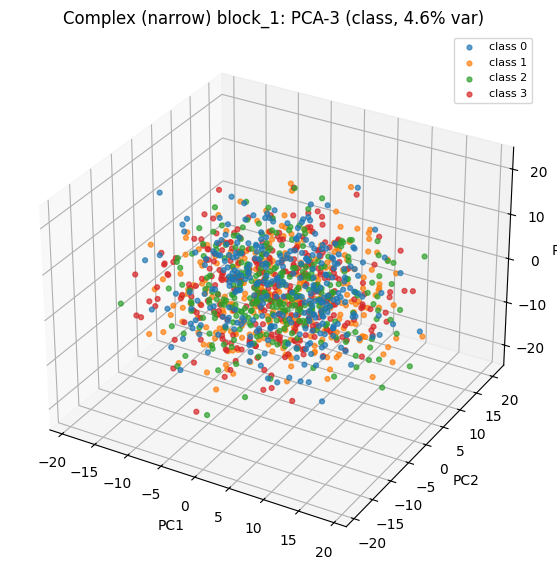

saved visualizations/geometry/complex_narrow_block_1_pca3_class.png


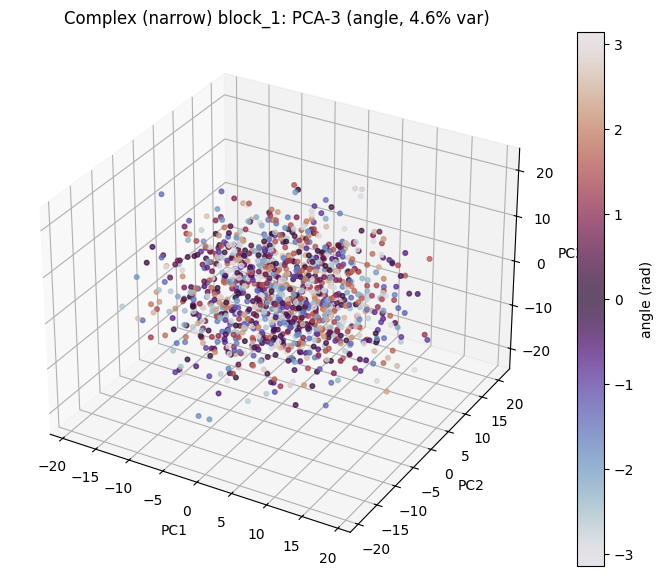

saved visualizations/geometry/complex_narrow_block_1_pca3_angle.png


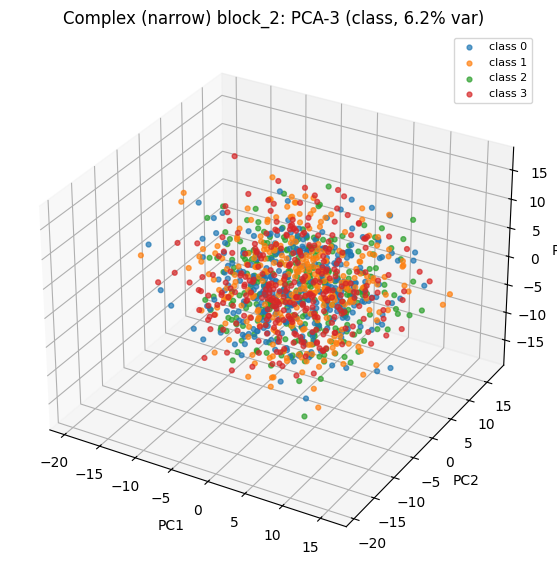

saved visualizations/geometry/complex_narrow_block_2_pca3_class.png


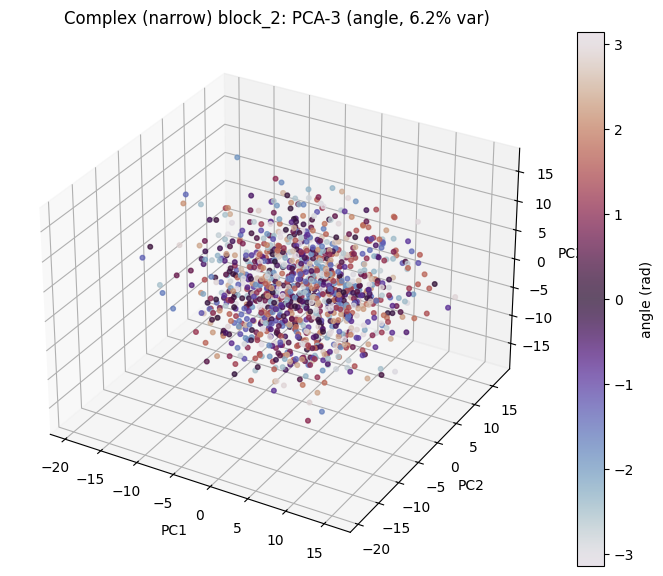

saved visualizations/geometry/complex_narrow_block_2_pca3_angle.png
Extracting and projecting activations for real_narrow...


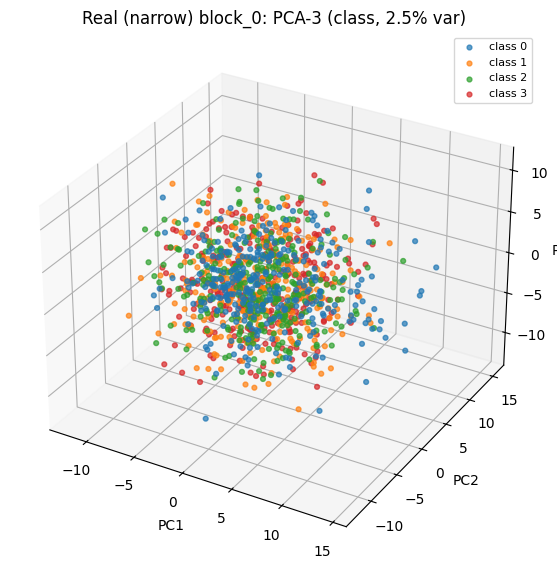

saved visualizations/geometry/real_narrow_block_0_pca3_class.png


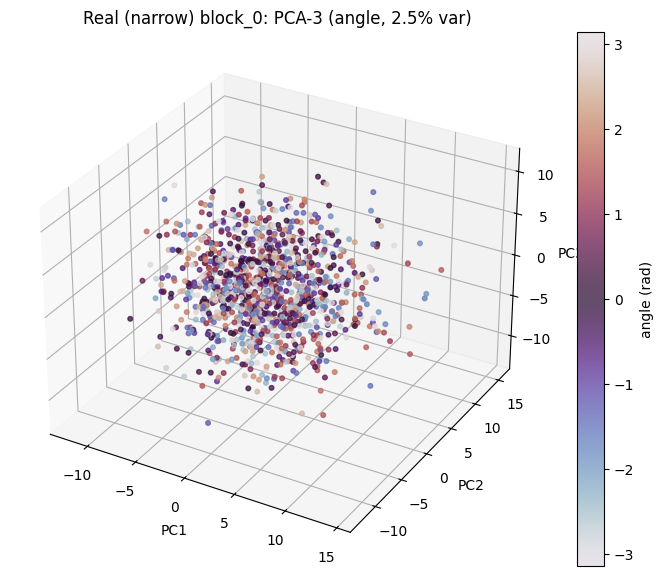

saved visualizations/geometry/real_narrow_block_0_pca3_angle.png


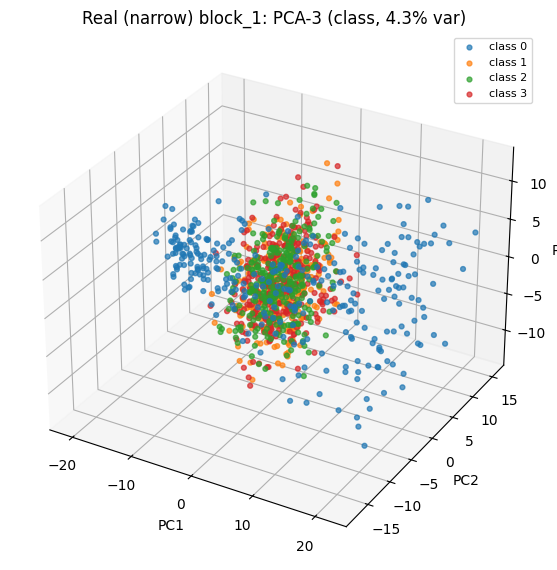

saved visualizations/geometry/real_narrow_block_1_pca3_class.png


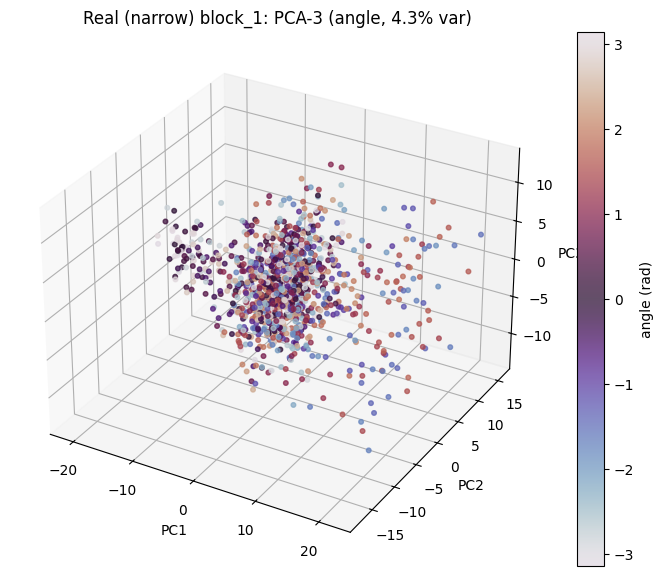

saved visualizations/geometry/real_narrow_block_1_pca3_angle.png


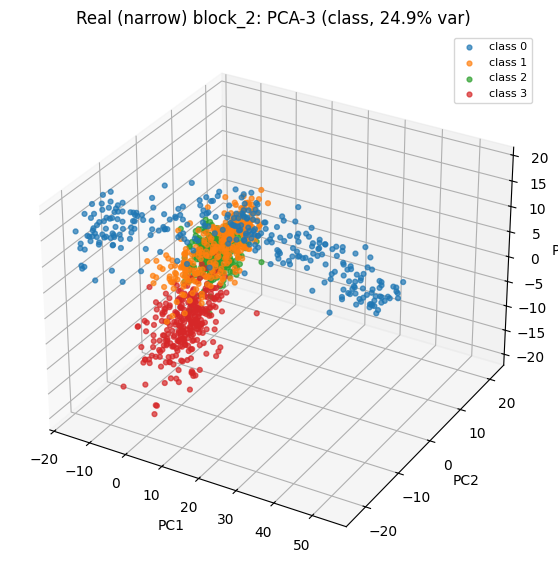

saved visualizations/geometry/real_narrow_block_2_pca3_class.png


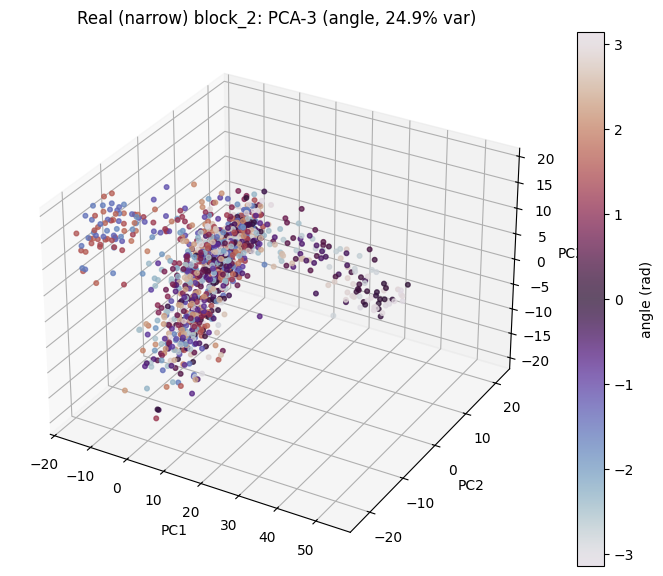

saved visualizations/geometry/real_narrow_block_2_pca3_angle.png
Extracting and projecting activations for real_full...


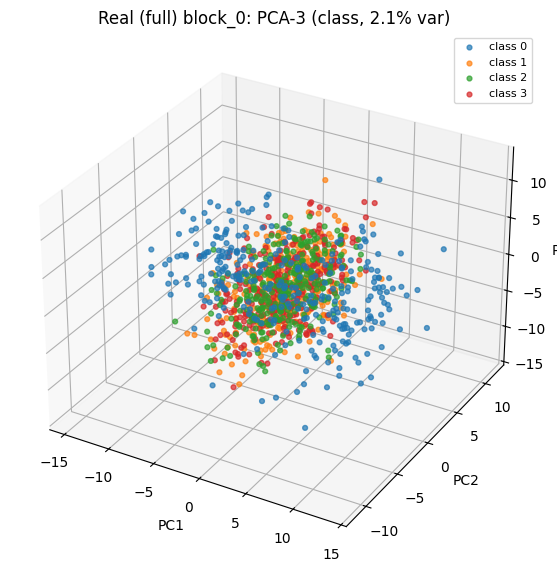

saved visualizations/geometry/real_full_block_0_pca3_class.png


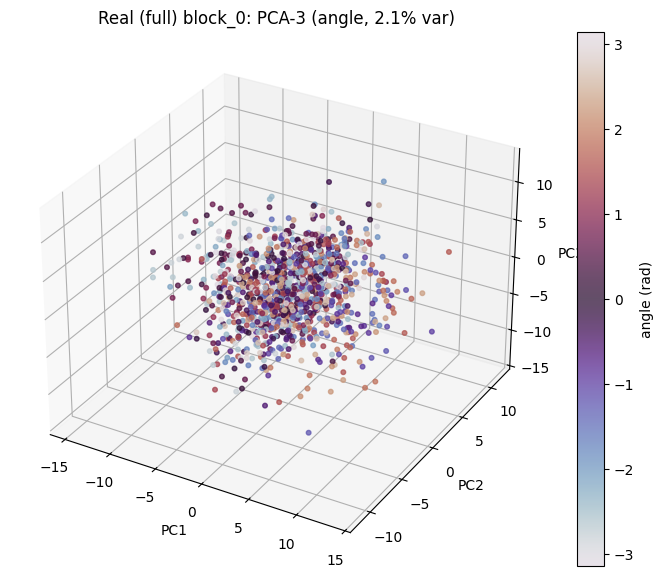

saved visualizations/geometry/real_full_block_0_pca3_angle.png


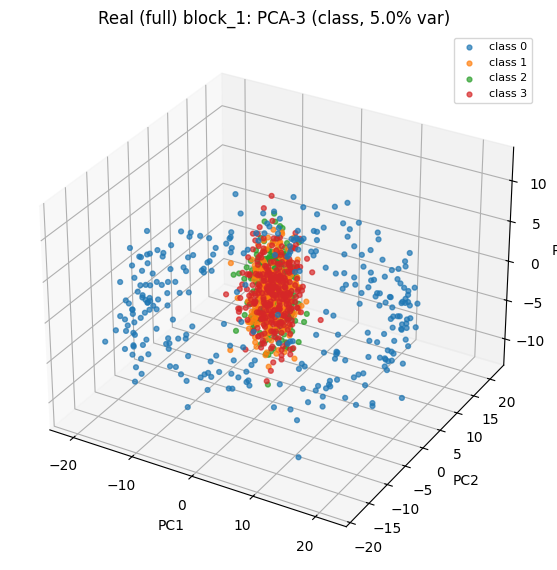

saved visualizations/geometry/real_full_block_1_pca3_class.png


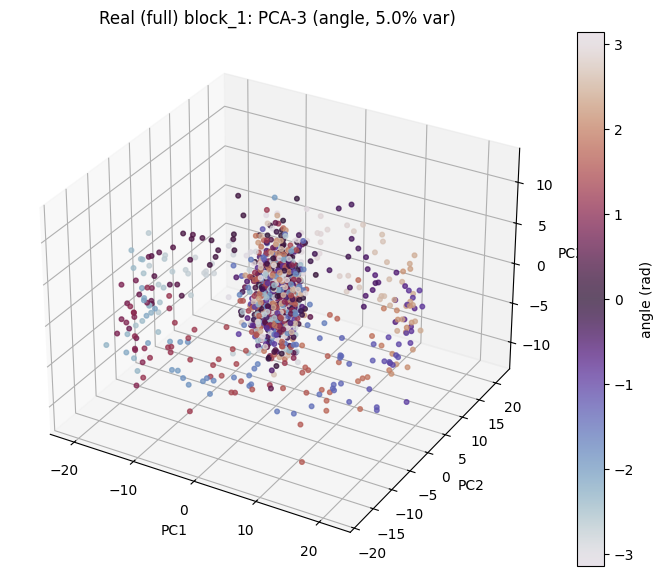

saved visualizations/geometry/real_full_block_1_pca3_angle.png


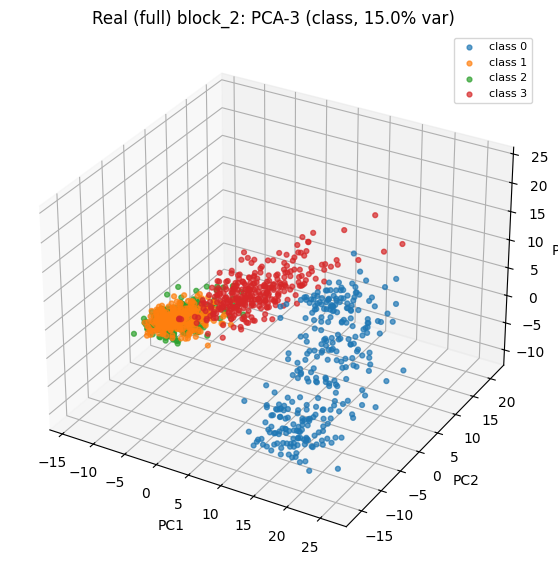

saved visualizations/geometry/real_full_block_2_pca3_class.png


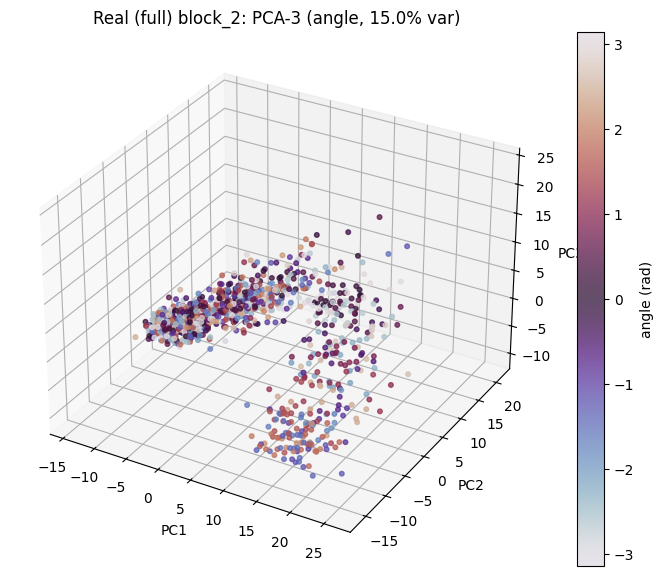

saved visualizations/geometry/real_full_block_2_pca3_angle.png


In [53]:
def extract_all_activations(model, iq, batch_size=512):
    extractor = ActivationExtractor(model)
    outs = {f'block_{i}': [] for i in range(len(model.features))}
    for i in range(0, len(iq), batch_size):
        acts = extractor.extract(iq[i:i + batch_size])
        for k in outs:
            outs[k].append(acts[k])
    extractor.remove()
    for k in outs:
        outs[k] = torch.cat(outs[k], dim=0)
    return outs


def pca3_projection(acts):
    flat = flatten_activation(acts)
    scaler = StandardScaler()
    x = scaler.fit_transform(flat)
    pca = PCA(n_components=3, random_state=42)
    z = pca.fit_transform(x)
    return z, pca.explained_variance_ratio_.sum()


def plot_3d_scatter(points, values, title, save_path, cmap='viridis', discrete=False):
    fig = plt.figure(figsize=(7, 5.8))
    ax = fig.add_subplot(111, projection='3d')

    if discrete:
        vals = np.asarray(values)
        for cls in np.unique(vals):
            mask = vals == cls
            ax.scatter(points[mask, 0], points[mask, 1], points[mask, 2], s=12, alpha=0.7, label=f'class {cls}')
        ax.legend(fontsize=8)
    else:
        sc = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=values, cmap=cmap, s=11, alpha=0.75)
        fig.colorbar(sc, ax=ax, label='angle (rad)')

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    fig.tight_layout()
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'saved {save_path}')


repr_results = {}
for run_name, model in models.items():
    print(f'Extracting and projecting activations for {run_name}...')
    acts = extract_all_activations(model, repr_iq)
    repr_results[run_name] = {}
    for block_name, block_acts in acts.items():
        z, var_ratio = pca3_projection(block_acts)
        repr_results[run_name][block_name] = {'z': z, 'var_ratio': float(var_ratio)}

        class_path = VIZ_DIR / f'{run_name}_{block_name}_pca3_class.png'
        angle_path = VIZ_DIR / f'{run_name}_{block_name}_pca3_angle.png'

        plot_3d_scatter(
            z,
            repr_label,
            f'{RUNS[run_name][2]} {block_name}: PCA-3 (class, {var_ratio*100:.1f}% var)',
            class_path,
            discrete=True,
        )

        plot_3d_scatter(
            z,
            repr_theta,
            f'{RUNS[run_name][2]} {block_name}: PCA-3 (angle, {var_ratio*100:.1f}% var)',
            angle_path,
            cmap='twilight',
            discrete=False,
        )


## 7) Rotation Orbit Trajectories in Latent 3D

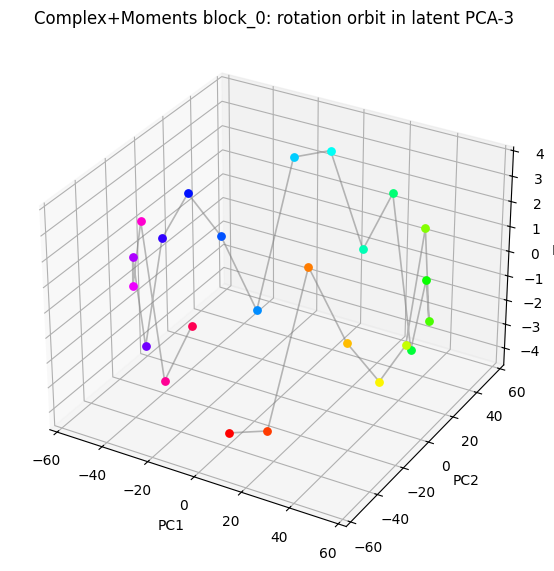

saved visualizations/geometry/complex_moment_block_0_rotation_orbit3d.png


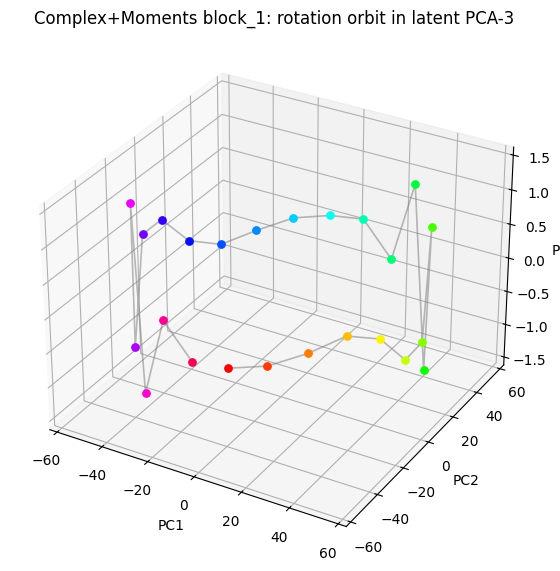

saved visualizations/geometry/complex_moment_block_1_rotation_orbit3d.png


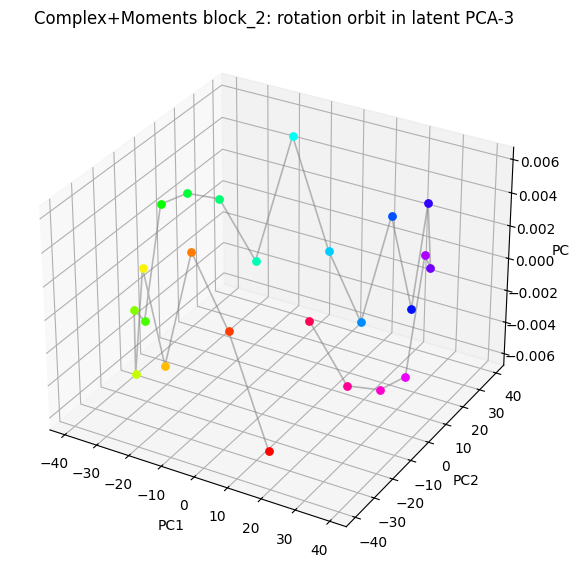

saved visualizations/geometry/complex_moment_block_2_rotation_orbit3d.png


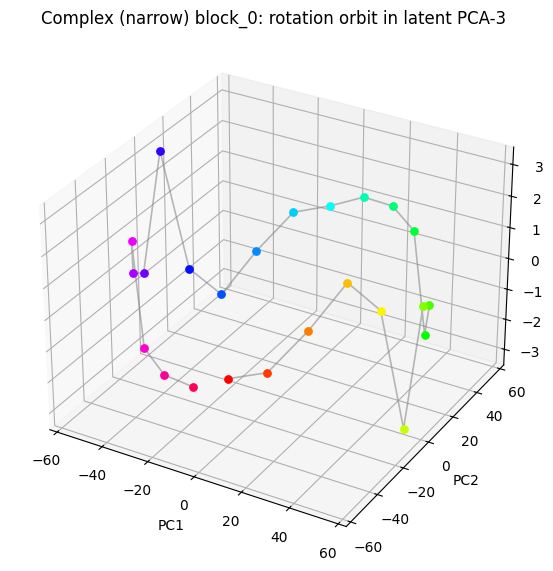

saved visualizations/geometry/complex_narrow_block_0_rotation_orbit3d.png


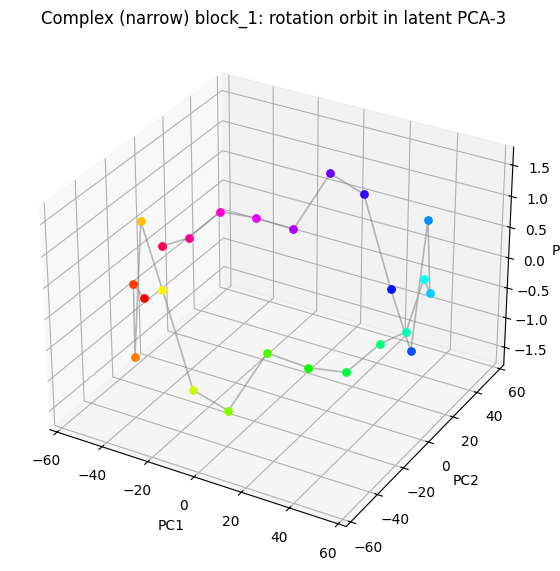

saved visualizations/geometry/complex_narrow_block_1_rotation_orbit3d.png


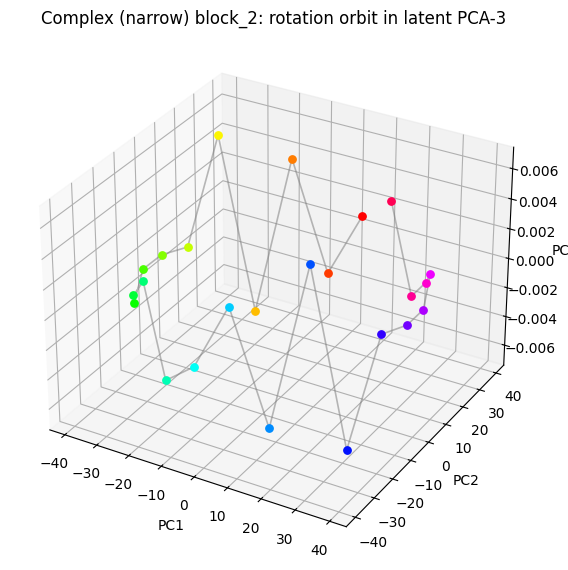

saved visualizations/geometry/complex_narrow_block_2_rotation_orbit3d.png


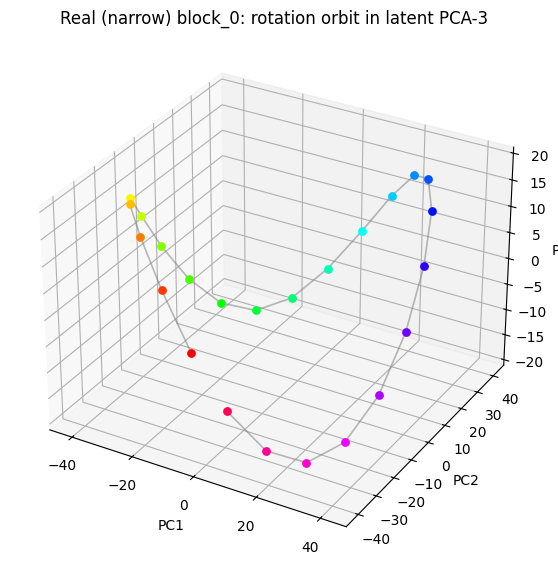

saved visualizations/geometry/real_narrow_block_0_rotation_orbit3d.png


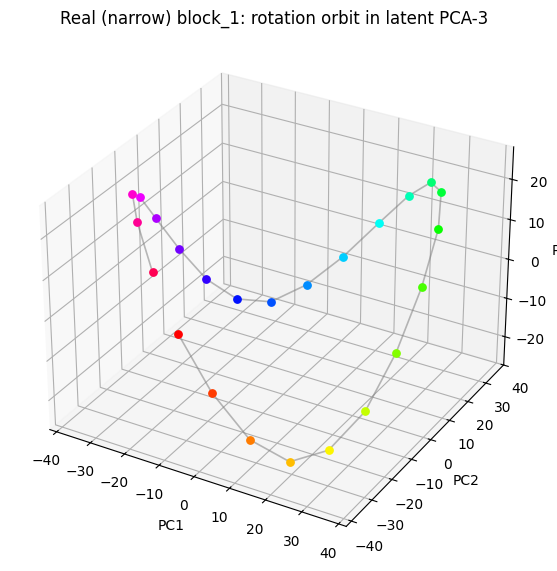

saved visualizations/geometry/real_narrow_block_1_rotation_orbit3d.png


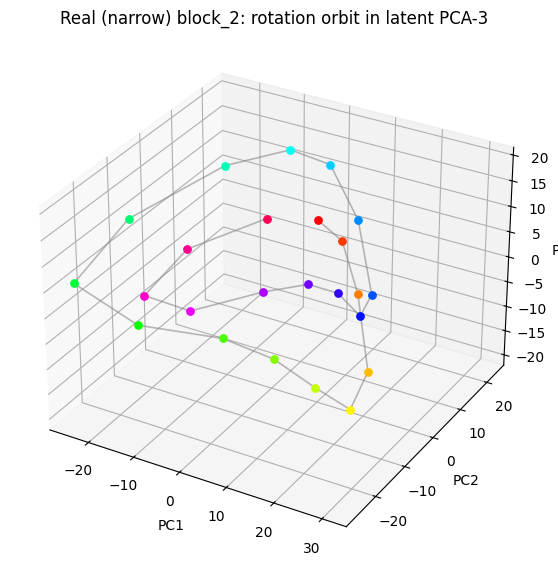

saved visualizations/geometry/real_narrow_block_2_rotation_orbit3d.png


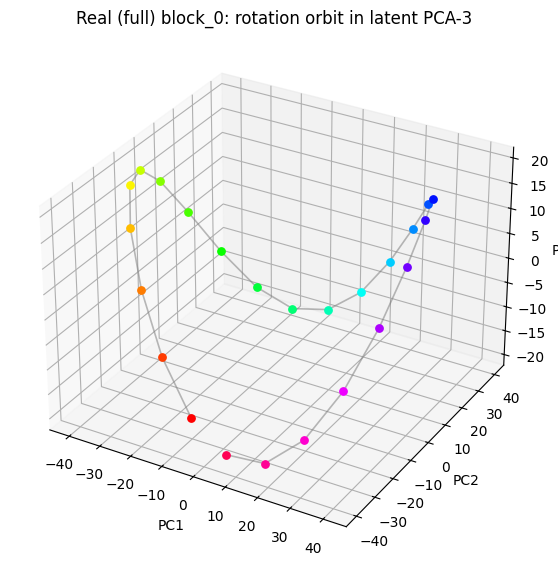

saved visualizations/geometry/real_full_block_0_rotation_orbit3d.png


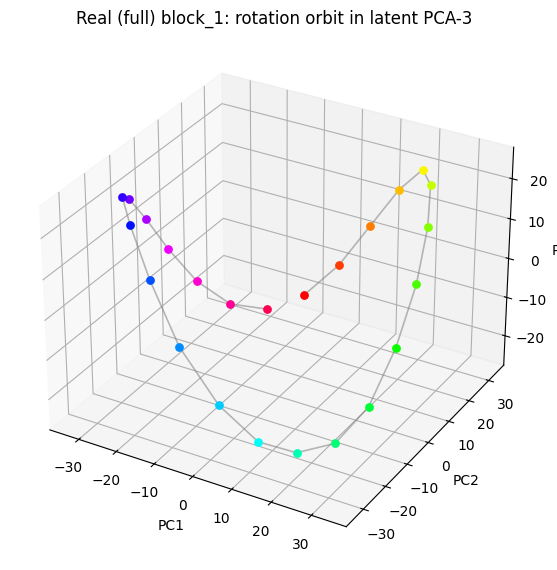

saved visualizations/geometry/real_full_block_1_rotation_orbit3d.png


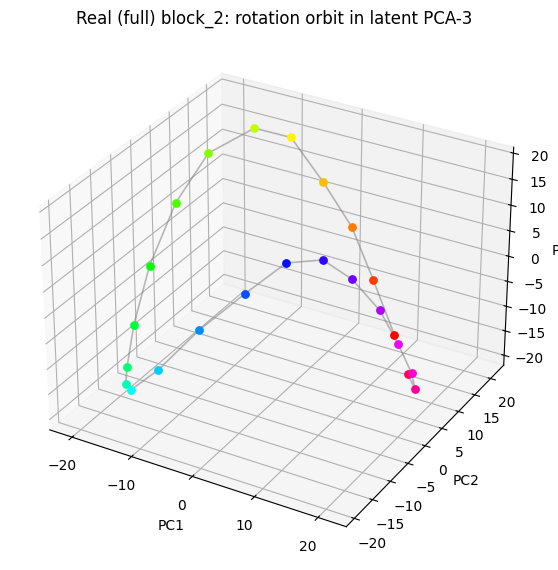

saved visualizations/geometry/real_full_block_2_rotation_orbit3d.png


In [54]:
def orbit_trajectory(model, block_name='block_1', mod='qpsk', n_angles=36):
    rng = np.random.default_rng(404)
    burst = generate_clean_burst(mod, cfg, rng)
    burst = add_awgn(burst, cfg.snr_db, rng)

    angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
    extractor = ActivationExtractor(model)
    samples = []

    for theta in angles:
        x_np = rotate_burst(burst, theta)[None, :]
        x = to_model_input(x_np)
        acts = extractor.extract(x)
        samples.append(flatten_activation(acts[block_name])[0])

    extractor.remove()
    X = np.array(samples)
    X = StandardScaler().fit_transform(X)
    z = PCA(n_components=3, random_state=42).fit_transform(X)
    return angles, z


def plot_orbit3d(run_name, block_name, angles, z):
    fig = plt.figure(figsize=(7, 5.8))
    ax = fig.add_subplot(111, projection='3d')

    for i in range(len(angles)):
        c = plt.cm.hsv(angles[i] / (2 * np.pi))
        ax.scatter(z[i, 0], z[i, 1], z[i, 2], c=[c], s=28)
    ax.plot(z[:, 0], z[:, 1], z[:, 2], color='gray', alpha=0.55, linewidth=1.2)

    ax.set_title(f'{RUNS[run_name][2]} {block_name}: rotation orbit in latent PCA-3')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    fig.tight_layout()
    out = VIZ_DIR / f'{run_name}_{block_name}_rotation_orbit3d.png'
    fig.savefig(out, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'saved {out}')


blocks = ['block_0', 'block_1', 'block_2']
for run_name, model in models.items():
    for block in blocks:
        angles, z = orbit_trajectory(model, block_name=block, mod='qpsk', n_angles=n_orbit_angles)
        plot_orbit3d(run_name, block, angles, z)


## 8) How Models Think: Perturbation Responses + Saliency

Computing perturbation diagnostics for complex_moment...
Computing perturbation diagnostics for complex_narrow...
Computing perturbation diagnostics for real_narrow...
Computing perturbation diagnostics for real_full...


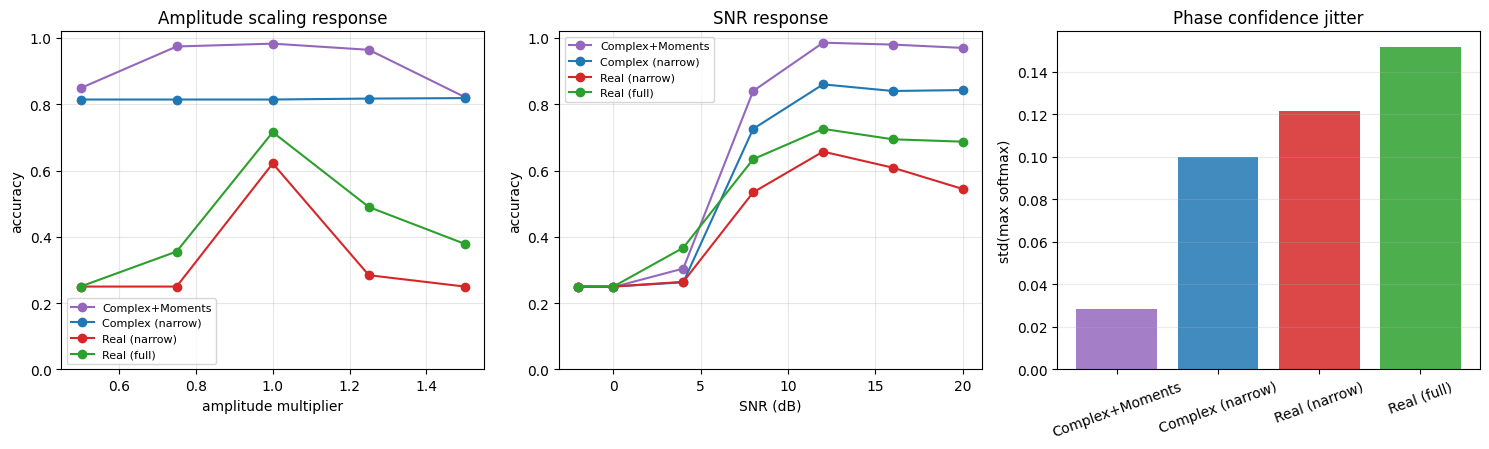

saved visualizations/geometry/perturbation_response.png


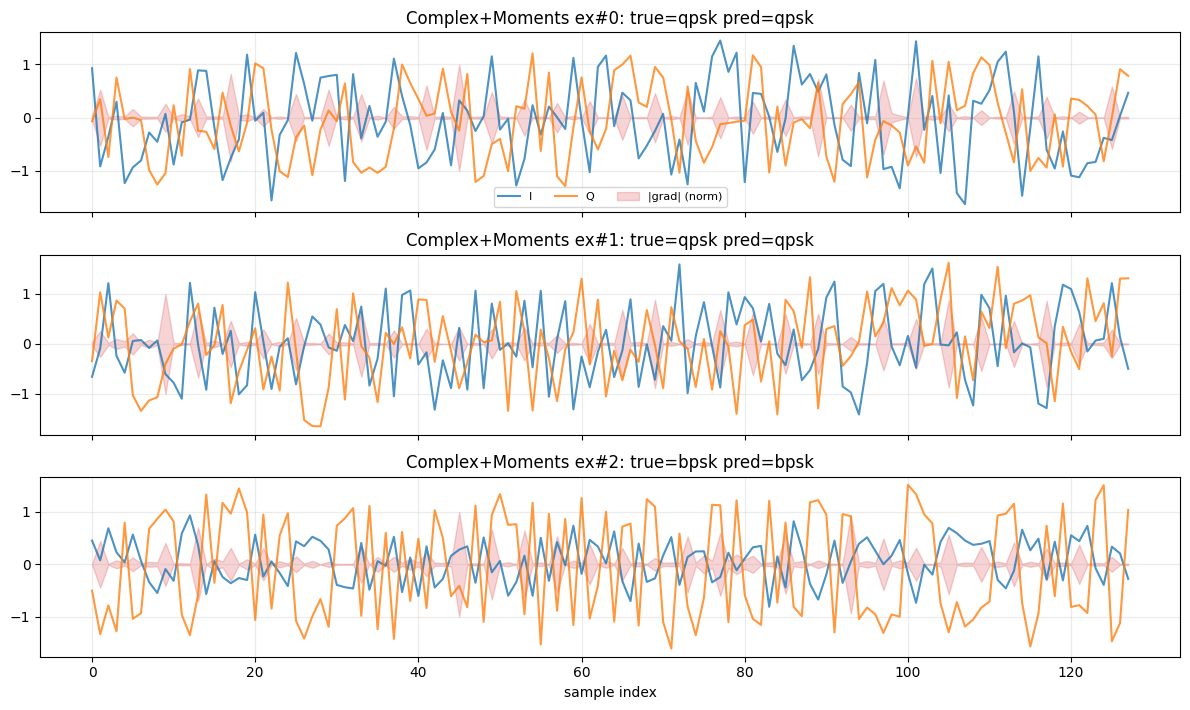

saved visualizations/geometry/complex_moment_saliency_examples.png


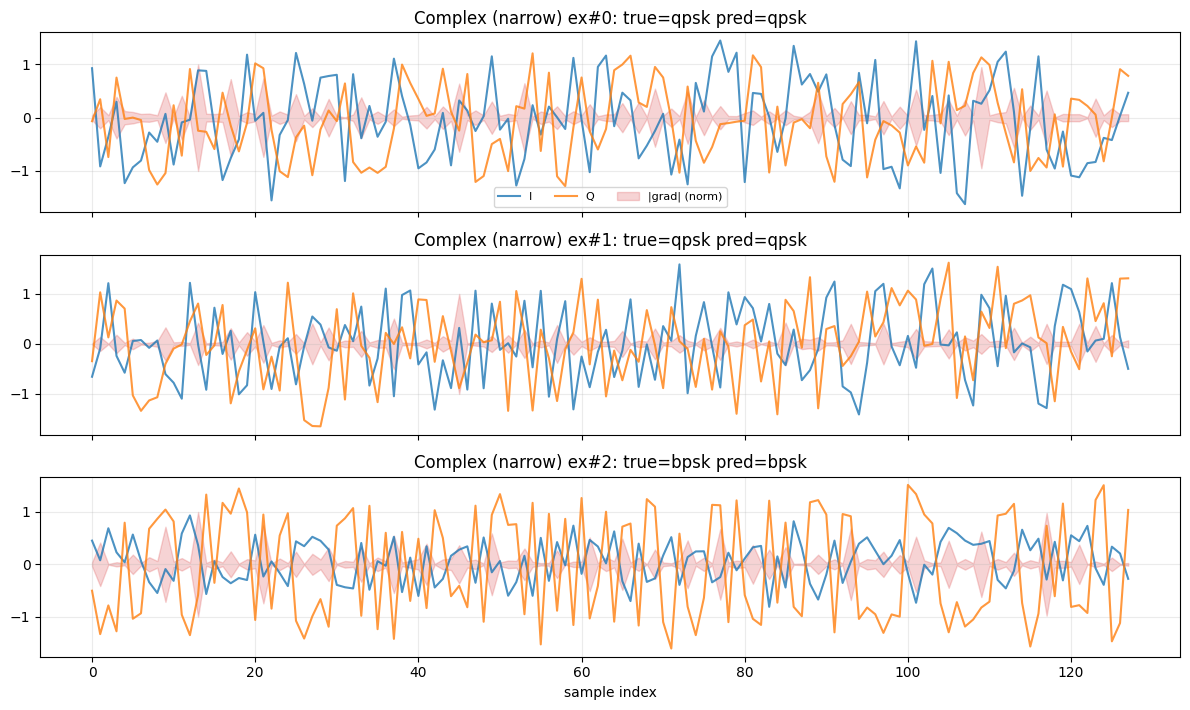

saved visualizations/geometry/complex_narrow_saliency_examples.png


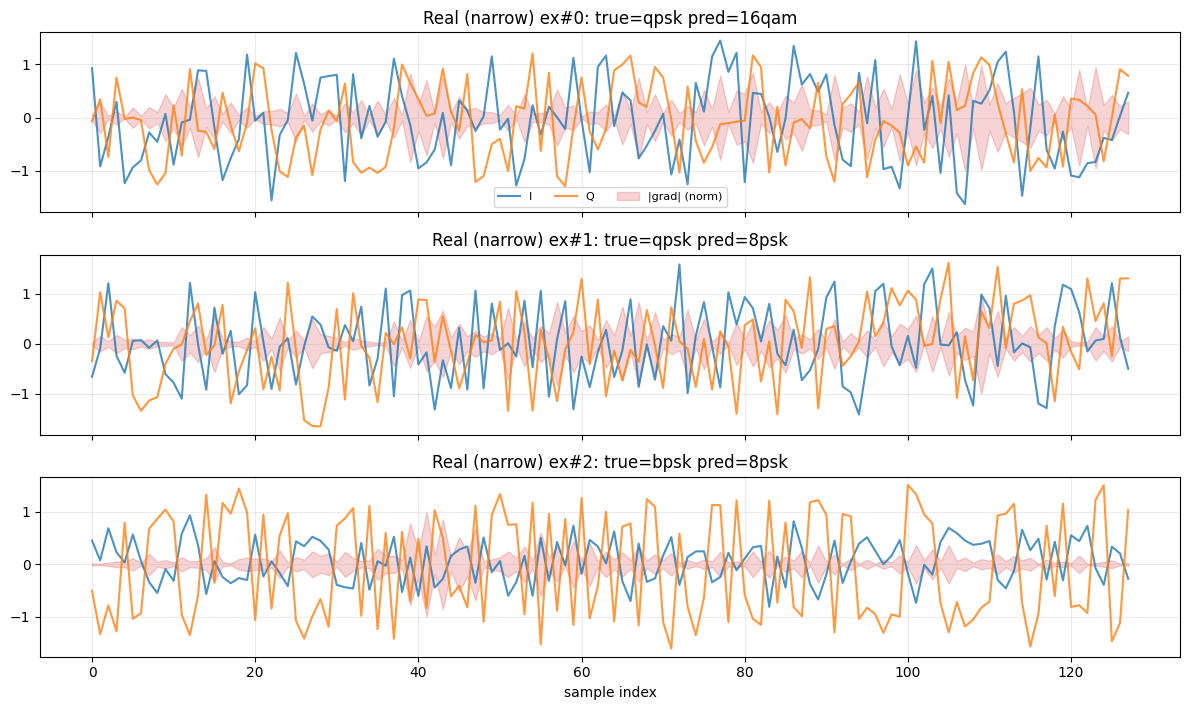

saved visualizations/geometry/real_narrow_saliency_examples.png


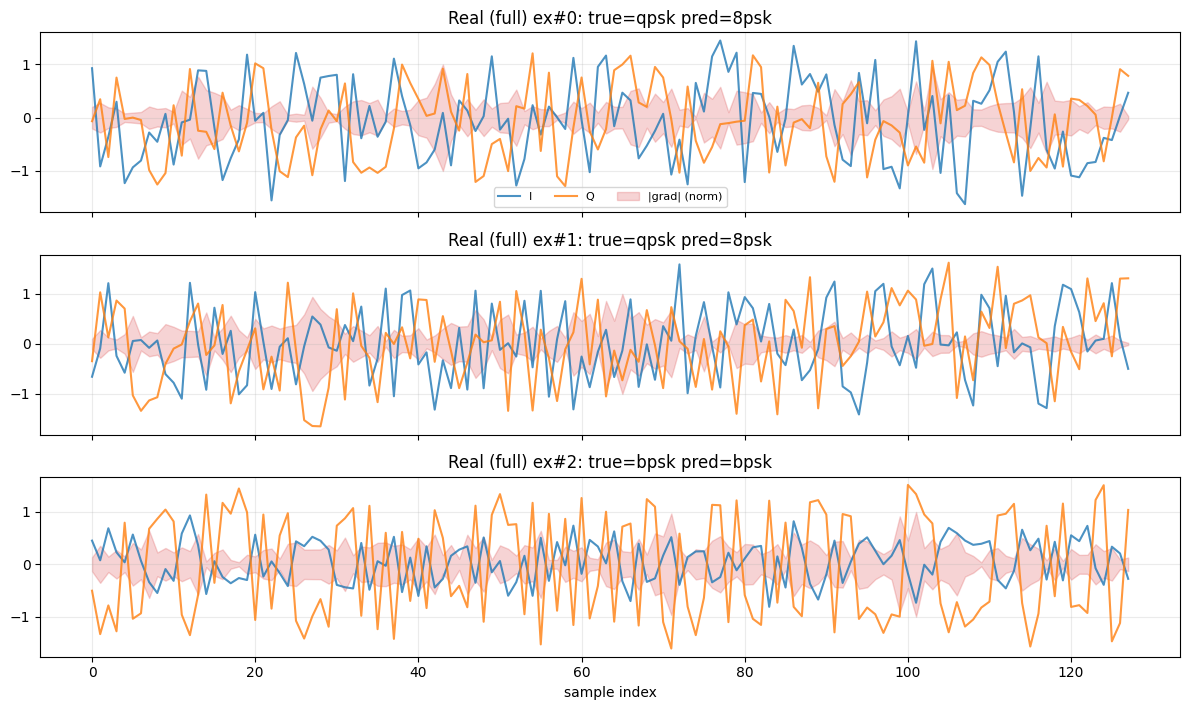

saved visualizations/geometry/real_full_saliency_examples.png


In [55]:
def build_phase_eval_set(mod_name='qpsk', n_signals=24, n_angles=24):
    rng = np.random.default_rng(505)
    angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
    iq_list = []
    y_list = []
    for _ in range(n_signals):
        burst = generate_clean_burst(mod_name, cfg, rng)
        burst = add_awgn(burst, cfg.snr_db, rng)
        for theta in angles:
            iq_list.append(rotate_burst(burst, theta))
            y_list.append(cfg.modulations.index(mod_name))
    return np.asarray(iq_list, dtype=np.complex64), np.asarray(y_list, dtype=np.int64), angles


def amplitude_sweep(model, scales=(0.5, 0.75, 1.0, 1.25, 1.5), n=1000):
    base = generate_dataset(n, cfg, -cfg.full_phase_deg, cfg.full_phase_deg, snr_db=cfg.snr_db, seed_offset=9000)
    results = []
    for s in scales:
        iq = to_model_input((base['iq'] * s).astype(np.complex64))
        label = torch.from_numpy(base['label']).to(device)
        loss, acc = evaluate_loss_acc(model, iq, label)
        probs = model_head_probs(model, iq)
        conf = probs.max(axis=1).mean()
        results.append((float(s), float(acc), float(conf), float(loss)))
    return results


def snr_sweep(model, snrs=(-2, 0, 4, 8, 12, 16, 20), n=1200):
    out = []
    for snr in snrs:
        data = generate_dataset(n, cfg, -cfg.full_phase_deg, cfg.full_phase_deg, snr_db=float(snr), seed_offset=9100 + int(snr * 10))
        iq = to_model_input(data['iq'])
        label = torch.from_numpy(data['label']).to(device)
        _, acc = evaluate_loss_acc(model, iq, label)
        probs = model_head_probs(model, iq)
        conf = probs.max(axis=1).mean()
        out.append((float(snr), float(acc), float(conf)))
    return out


def phase_jitter(model, n_signals=16, n_angles=24):
    iq, y, angles = build_phase_eval_set(mod_name='qpsk', n_signals=n_signals, n_angles=n_angles)
    probs = model_head_probs(model, to_model_input(iq))
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == y).mean()
    conf_std = conf.std()
    tv = 0.5 * np.abs(np.roll(probs, -1, axis=0) - probs).sum(axis=1).mean()
    return {'angles': angles, 'acc': float(acc), 'conf_jitter': float(conf_std), 'tv': float(tv)}


def plot_perturbation_responses(all_results):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

    for run_name, res in all_results.items():
        color = RUNS[run_name][1]
        label = RUNS[run_name][2]

        amp = np.array(res['amp'])
        axes[0].plot(amp[:, 0], amp[:, 1], '-o', color=color, label=label)

        snr = np.array(res['snr'])
        axes[1].plot(snr[:, 0], snr[:, 1], '-o', color=color, label=label)

        axes[2].bar(label, res['phase']['conf_jitter'], color=color, alpha=0.85)

    axes[0].set_title('Amplitude scaling response')
    axes[0].set_xlabel('amplitude multiplier')
    axes[0].set_ylabel('accuracy')
    axes[0].set_ylim(0, 1.02)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('SNR response')
    axes[1].set_xlabel('SNR (dB)')
    axes[1].set_ylabel('accuracy')
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(True, alpha=0.3)

    axes[2].set_title('Phase confidence jitter')
    axes[2].set_ylabel('std(max softmax)')
    axes[2].tick_params(axis='x', rotation=20)
    axes[2].grid(True, alpha=0.25, axis='y')

    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    out = VIZ_DIR / 'perturbation_response.png'
    fig.savefig(out, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'saved {out}')


def saliency_for_example(model, iq_np):
    model.eval()
    x = to_model_input(iq_np[None, :]).clone().detach().requires_grad_(True)
    logits = model(x)
    pred = int(logits.argmax(1).item())
    score = logits[0, pred]
    model.zero_grad(set_to_none=True)
    score.backward()
    grad = x.grad.detach()[0]
    sal = torch.abs(grad).cpu().numpy()
    return pred, sal, grad.real.cpu().numpy(), grad.imag.cpu().numpy()


def plot_saliency_examples(run_name, model, n_examples=4):
    data = generate_dataset(max(32, n_examples * 8), cfg, -cfg.full_phase_deg, cfg.full_phase_deg, snr_db=cfg.snr_db, seed_offset=12000)

    fig, axes = plt.subplots(n_examples, 1, figsize=(12, 2.4 * n_examples), sharex=True)
    if n_examples == 1:
        axes = [axes]

    for i in range(n_examples):
        iq = data['iq'][i]
        label = int(data['label'][i])
        pred, sal, grad_r, grad_i = saliency_for_example(model, iq)

        t = np.arange(len(iq))
        ax = axes[i]
        ax.plot(t, iq.real, color='tab:blue', alpha=0.8, label='I')
        ax.plot(t, iq.imag, color='tab:orange', alpha=0.8, label='Q')
        sal_norm = sal / (sal.max() + 1e-8)
        ax.fill_between(t, -sal_norm, sal_norm, color='tab:red', alpha=0.20, label='|grad| (norm)')
        ax.set_title(f'{RUNS[run_name][2]} ex#{i}: true={cfg.modulations[label]} pred={cfg.modulations[pred]}')
        ax.grid(True, alpha=0.25)

    axes[0].legend(ncol=3, fontsize=8)
    axes[-1].set_xlabel('sample index')
    fig.tight_layout()
    out = VIZ_DIR / f'{run_name}_saliency_examples.png'
    fig.savefig(out, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'saved {out}')


thinking_results = {}
for run_name, model in models.items():
    print(f'Computing perturbation diagnostics for {run_name}...')
    thinking_results[run_name] = {
        'amp': amplitude_sweep(model, scales=(0.5, 0.75, 1.0, 1.25, 1.5), n=700 if FAST_MODE else 2400),
        'snr': snr_sweep(model, snrs=(-2, 0, 4, 8, 12, 16, 20), n=700 if FAST_MODE else 2400),
        'phase': phase_jitter(model, n_signals=10 if FAST_MODE else 30, n_angles=n_phase_eval),
    }

plot_perturbation_responses(thinking_results)

for run_name, model in models.items():
    plot_saliency_examples(run_name, model, n_examples=3 if FAST_MODE else 5)


## 9) Comparative Scorecard (How Each Model “Thinks”)

saved visualizations/geometry/model_thinking_scorecard.csv


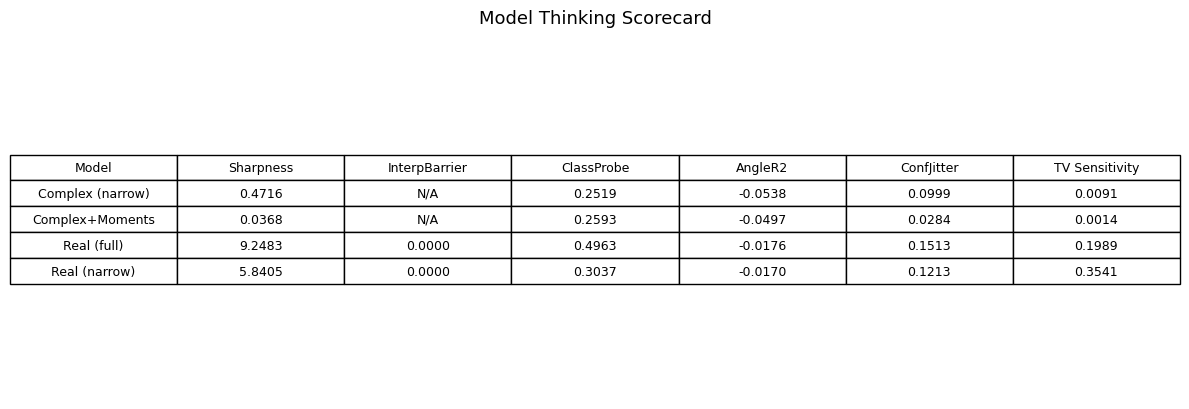

saved visualizations/geometry/model_thinking_scorecard.png

Interpretation hints:
- Lower sharpness proxy means flatter local basin around checkpoint.
- Lower angle R2 with high class probe can indicate stronger rotation invariance.
- Lower confidence jitter/TV means outputs are steadier under phase changes.


In [56]:
def compute_probe_metrics(model, n=1600):
    data = generate_dataset(n, cfg, -cfg.full_phase_deg, cfg.full_phase_deg, snr_db=cfg.snr_db, seed_offset=13000)
    iq = to_model_input(data['iq'])
    labels = data['label']
    theta = data['theta']

    extractor = ActivationExtractor(model)
    reps = []
    for i in range(0, len(iq), 512):
        acts = extractor.extract(iq[i:i + 512])
        reps.append(flatten_activation(acts['block_1']))
    extractor.remove()

    X = np.concatenate(reps, axis=0)
    y_cls = labels
    y_sin = np.sin(theta)
    y_cos = np.cos(theta)

    split = int(0.7 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_cls_train, y_cls_test = y_cls[:split], y_cls[split:]
    y_sin_train, y_sin_test = y_sin[:split], y_sin[split:]
    y_cos_train, y_cos_test = y_cos[:split], y_cos[split:]

    n_comp = min(50, X_train.shape[0] - 1, X_train.shape[1])

    cls_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp, random_state=42)),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')),
    ])
    cls_pipe.fit(X_train, y_cls_train)
    class_acc = accuracy_score(y_cls_test, cls_pipe.predict(X_test))

    reg_sin = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp, random_state=42)),
        ('reg', Ridge(alpha=1.0)),
    ])
    reg_cos = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp, random_state=42)),
        ('reg', Ridge(alpha=1.0)),
    ])
    reg_sin.fit(X_train, y_sin_train)
    reg_cos.fit(X_train, y_cos_train)
    r2_sin = r2_score(y_sin_test, reg_sin.predict(X_test))
    r2_cos = r2_score(y_cos_test, reg_cos.predict(X_test))
    angle_r2 = 0.5 * (r2_sin + r2_cos)

    return float(class_acc), float(angle_r2)


rows = []
for run_name, model in models.items():
    sharp = landscape_results[run_name]['sharpness_proxy'] if run_name in landscape_results else float('nan')

    interp_barrier = float('nan')
    for (a, b), res in interpolation_results.items():
        if run_name in (a, b):
            interp_barrier = max(interp_barrier, res['barrier']) if not math.isnan(interp_barrier) else res['barrier']

    cls_acc, angle_r2 = compute_probe_metrics(model, n=900 if FAST_MODE else 2400)
    conf_jitter = thinking_results[run_name]['phase']['conf_jitter']
    tv = thinking_results[run_name]['phase']['tv']

    rows.append({
        'run': run_name,
        'label': RUNS[run_name][2],
        'sharpness_proxy': sharp,
        'interpolation_barrier': interp_barrier,
        'block1_class_probe_acc': cls_acc,
        'block1_angle_r2': angle_r2,
        'phase_conf_jitter': conf_jitter,
        'phase_tv_sensitivity': tv,
    })

rows = sorted(rows, key=lambda r: r['label'])

csv_path = VIZ_DIR / 'model_thinking_scorecard.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)
print(f'saved {csv_path}')


fig, ax = plt.subplots(figsize=(12, 2 + 0.55 * len(rows)))
ax.axis('off')

col_labels = [
    'Model',
    'Sharpness',
    'InterpBarrier',
    'ClassProbe',
    'AngleR2',
    'ConfJitter',
    'TV Sensitivity',
]

def fmt(x):
    if isinstance(x, float) and math.isnan(x):
        return 'N/A'
    return f'{x:.4f}' if isinstance(x, float) else str(x)

cell_text = []
for r in rows:
    cell_text.append([
        r['label'],
        fmt(r['sharpness_proxy']),
        fmt(r['interpolation_barrier']),
        fmt(r['block1_class_probe_acc']),
        fmt(r['block1_angle_r2']),
        fmt(r['phase_conf_jitter']),
        fmt(r['phase_tv_sensitivity']),
    ])

table = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

ax.set_title('Model Thinking Scorecard', fontsize=13, pad=12)
score_png = VIZ_DIR / 'model_thinking_scorecard.png'
fig.tight_layout()
fig.savefig(score_png, dpi=160, bbox_inches='tight')
plt.show()
print(f'saved {score_png}')

print('\nInterpretation hints:')
print('- Lower sharpness proxy means flatter local basin around checkpoint.')
print('- Lower angle R2 with high class probe can indicate stronger rotation invariance.')
print('- Lower confidence jitter/TV means outputs are steadier under phase changes.')


## 10) Quick Summary

In [57]:
print('=' * 72)
print('Interpretability-first notebook complete')
print('=' * 72)
print('Generated files include:')
print('- <run>_loss_landscape_contour.png')
print('- <run>_loss_landscape_surface.png')
print('- interpolation_barriers.png')
print('- <run>_<block>_pca3_class.png / _pca3_angle.png')
print('- <run>_<block>_rotation_orbit3d.png')
print('- perturbation_response.png')
print('- <run>_saliency_examples.png')
print('- model_thinking_scorecard.csv / .png')
print('Output directory:', VIZ_DIR)


Interpretability-first notebook complete
Generated files include:
- <run>_loss_landscape_contour.png
- <run>_loss_landscape_surface.png
- interpolation_barriers.png
- <run>_<block>_pca3_class.png / _pca3_angle.png
- <run>_<block>_rotation_orbit3d.png
- perturbation_response.png
- <run>_saliency_examples.png
- model_thinking_scorecard.csv / .png
Output directory: visualizations/geometry
